<a href="https://colab.research.google.com/github/SteTerro/RentOrBuy/blob/main/RentOrBuy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rent or Buy Problem

The *Rent or Buy Problem* is a classic problem in online algorithm theory that models a decision-making situation where an agent must choose between renting equipment day by day or purchasing it outright, without knowing in advance the actual duration of its use.

In the paper *Algorithms with Predictions* by Mitzenmacher and Vassilvitskii, frameworks were presented that combine a classical approach to online algorithms with Machine Learning techniques to improve decision-making performance. The applications of this approach are numerous, such as *Learned Bloom Filters* or *Caching*. One of the models they proposed aimed to solve the *Rent or Buy* problem presented as the *Ski Rental Problem*. The objective is to present an algorithm that can be optimal when the predictor is correct, while still maintaining minimum theoretical worst-case guarantees when the predictor is wrong.

### Problem Formulation

The problem simulates the scenario of a skier (or tennis player in our case) at the beginning of the season who must decide whether to rent or buy their equipment:

- Rental cost: 1 dollar per day.
- Purchase cost: A fixed amount of *b* dollars.
- The uncertainty: The skier does not know in advance how many days $(d^*)$ they will actually ski (or play) during the season.

The goal is to minimize total expenditure without knowing the future.

In this notebook, we aim to address this problem using an alternative approach. The two classical algorithms for solving a *Rent or Buy* problem are:

1. *Offline Algorithm (Optimal)*: With perfect knowledge of *D*, the optimal cost is `min(D × r, b)`

2. *Deterministic Online Algorithm*: Rent until the cumulative cost reaches *b*, then purchase


## Pre-Processing

We start by loading the necessary libraries:

- **numpy** and **pandas**: Tools for data manipulation and analysis, allowing us to load and manage meteorological datasets in tabular format
- **scikit-learn**: The library used for loading machine learning models and cleaning the data
- **matplotlib.pyplot**: Library for graphical visualization of results

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

The dataset is taken from Kaggle. Since no skiing datasets were available, a tennis weather dataset was used instead. This dataset contains weather conditions and whether tennis can be played on a given day, which serves as a suitable proxy for the Rent or Buy problem in the context of equipment rental decisions.

The dataset has 6 feature:
- *Day:* incrementing daily, accounting for real calendar dates (including leap years).
- *Outlook:* The general weather outlook on that day - categories include Sunny, Overcast, or Rain.
- *Temperature:* The temperature conditions on that day — categories include Hot, Mild, or Cool.
- *Humidity:* The humidity level on that day — categories include High or Normal.
- *Wind:* The wind condition on that day — categories include Weak or Strong.
- *Play:* The target variable: whether tennis was played on that day (Yes) or not (No).

> Feature description taken from the kaggle page

I will begin by downloading the dataset. On Google Colab, I downloaded the file from the official [Kaggle repository](https://www.kaggle.com/datasets/milapgohil/play-tennis-dataset-weather-based-classifier?resource=download), then uploaded it to Google Drive within a "Data" folder and read it from there. Alternatively, when running the Notebook locally, I used the Kaggle API directly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = 'drive/MyDrive/Data/play_tennis_dataset.csv'

try:
    with open(file_path, 'r') as f:
        contenuto = f.read()
except FileNotFoundError:
    print(f"File non trovato. Controlla il percorso: {file_path}")

df = pd.read_csv(file_path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Day,Outlook,Temperature,Humidity,Wind,Play
0,D1,Overcast,Mild,Normal,Strong,Yes
1,D2,Sunny,Mild,Normal,Strong,Yes
2,D3,NaN,Mild,High,Strong,No
3,D4,Sunny,Mild,High,Weak,Yes
4,D5,Sunny,Cool,Normal,Strong,Yes


In [ ]:
import kagglehub

path = kagglehub.dataset_download("sarveshchhetri/play-tennis-practice-dataset-for-classification")
print("Path to dataset files:", path)

df = pd.read_csv(f"play_tennis_dataset.csv")
print(df.head())

Using Colab cache for faster access to the 'play-tennis-practice-dataset-for-classification' dataset.
Path to dataset files: /kaggle/input/play-tennis-practice-dataset-for-classification


FileNotFoundError: [Errno 2] No such file or directory: 'play_tennis_dataset.csv'

The dataset contains several missing values. In a standard workflow, I would have removed incomplete observations or imputed them. However, I have deliberately chosen to retain them to preserve the authenticity of the experiment. Since it is unclear whether these gaps follow a real-world pattern or are merely random, I have decided to treat these flawed data points as "inaccurate weather forecasts."

The goal is to prevent the predictor from achieving excessive accuracy by perfectly memorizing historical data and predicting the exact number of skiable days. In reality, machine learning predictions are inherently imperfect.

In a real-world application, I would have implemented a predictive model based on a moving average (e.g., using the previous 7 days to predict the next 3). Due to the time constraints of this activity, I opted for a simplification, predicting the entire month based on previous periods. I view the development of a sliding-window model as a primary objective for future iterations of this project

In [ ]:
print(df.isnull().sum())
# print(df.isnull().sum())
# df = df.dropna()
X = df.drop('Play', axis=1)

y = df['Play'].apply(lambda x: 1 if x == 'Yes' else 0)

le = LabelEncoder()
for col in X.columns:
    X[col] = le.fit_transform(X[col])

Day              0
Outlook        399
Temperature    333
Humidity       233
Wind           366
Play             0
dtype: int64


At this stage, we visualize datasets X (features) and Y (labels). Additionally, we calculate the total number of days where play was actually possible.

In [ ]:
print(X.shape, y.shape)
print(X.head())
print(y.head())

print("Number of 1's in y:", y.sum())
duration = y.sum()

(6666, 5) (6666,)
   Day  Outlook  Temperature  Humidity  Wind
0    0        0            2         1     0
1   11        2            2         1     0
2   22        3            2         0     0
3   25        2            2         0     1
4   26        2            0         1     0
0    1
1    1
2    0
3    1
4    1
Name: Play, dtype: int64
Number of 1's in y: 4080


At this stage, I am splitting the dataset into two distinct subsets: the training set and the testing set. This step is crucial to ensure that the model evaluation occurs on data "unseen" during the learning phase.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
# print(X_train.head())
# print(X_test.head())
# print(y_train.head())
# print(y_test.head())

(5332, 5) (1334, 5) (5332,) (1334,)


I will define the purchase cost as 25 and the rental cost as 1.

In [ ]:
buy_price = 25
rent_price = 1

## Algorithms

 1. **Ideal Deterministic Strategy (Offline Optimal)**

In this scenario, we assume perfect knowledge of $d^{*}$
 , the exact number of days available for play. Since the future is known beforehand, the algorithm can always implement the offline optimal solution.

The algorithm has optimal solution: `min(D × r, b)`


In [ ]:
def offline_rent_or_buy(days, rent, buy):
    total_days = sum(days)
    return min(total_days * rent, buy)

1. **Classical Deterministic Strategy (Online)**

In the absence of forecasts, there is a simple strategy that guarantees a competitive ratio of 2 (i.e., you never spend more than double compared to someone who already knows the future):
The algorithm: You rent skis for the first $b$ days and buy them on day $b+1$.

If the season lasts less than b days, you have paid the optimal price. If it lasts longer, you spend a maximum of $2b$, which is less than double the optimal cost (the advance purchase).

In [ ]:
def deterministic_rent_or_buy(days, rent, buy, VERBOSE=False):
    cost = 0
    days_counter = 0

    for day in days:
        if day == 1:
            if days_counter < buy:
                cost += rent
                if VERBOSE:
                    print(f"Day {days_counter}: Renting equipment, Total cost: {cost}")
            else:
                cost += buy
                if VERBOSE:
                    print(f"Day {days_counter}: Buying equipment on break-even day, Total cost: {cost}")
                return cost
            days_counter +=1
    return cost


3. **Prediction-Based Approach (Machine Learning)**

Assuming that the tennis player has access to a prediction $h(d)$ regarding the length of the season; we can therefore attempt to improve their decision-making. Also, assume we have a prediction error $ \eta = \left\lvert h(d) - d^{*} \right\rvert$

If we follow the prediction blindly (buying immediately if $h(d)>b$, otherwise always renting), the total cost will be equal to the optimal cost plus the prediction error ($\eta$).

If the prediction turns out to be completely wrong, the player could end up spending much more than double the necessary amount.

To balance the benefits of predictions with the need for error protection, Mitzenmacher and Vassilvitskii proposed introducing a parameter $\lambda \in [0,1]$ to calibrate the algorithm, so that
if the prediction suggests a long season $(h(d)>b)$, one purchases on day $\lambda b$; so the purchase is made earlier compared to the deterministic online algorithm.
Otherwise, the purchase is made on day $b/\lambda$ (meaning the purchase is delayed).

This approach allows the system to be consistent (optimal performance if the prediction is correct, equal to the offline algorithm) and robust (performance limited by an acceptable worst-case scenario even if the prediction is totally wrong, it backup to  the worst-case of the online algorithm).

In [ ]:
def ml_rent_or_buy(X_train, y_train, X_test, y_test, rent, buy, lambd=0.5, VERBOSE=False):
    cost = 0
    day_counter = 0

    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)
    daily_predictions = model.predict(X_test)

    if daily_predictions.sum() > buy:
        purchase_day = max(1, int(buy * lambd))
    else:
        purchase_day = int(buy / lambd)
    if VERBOSE:
        print(f"lambd: {lambd}")
        print(f"DAily predictions sum: {daily_predictions.sum()}")
        print(f"buy = {buy}")
        print(f"Purchase day set to: {purchase_day}")

    for day in y_test:
        if day == 1:
          if day_counter == purchase_day:
              cost += buy
              if VERBOSE:
                    print(f"Day {day_counter}: Buying equipment, {cost}")
              return cost, "Buying equipment", daily_predictions
          elif day_counter < buy:
              cost += rent
              if VERBOSE:
                    print(f"Day {day_counter}: Renting equipment, {cost}")
          else:
              cost += buy
              if VERBOSE:
                    print(f"Day {day_counter}: Buying equipment, {cost}")
              return cost, "Renting equipment", daily_predictions
          day_counter += 1
    return cost, "Renting equipment", daily_predictions

I will now perform the simulation using the three defined approaches.

In [ ]:
cost_offline = offline_rent_or_buy(y_test, rent_price, buy_price)

cost_deterministic = deterministic_rent_or_buy(y_test, rent_price, buy_price)

ml_cost, action_taken, daily_predictions = ml_rent_or_buy(X_train, y_train, X_test, y_test, rent_price, buy_price, lambd=0.5)

predicted = daily_predictions.sum()
actual = y_test.sum()

print(f"--- PREDICTION REPORT ---")
print(f"Actual Season Duration: {actual} days")
print(f"Predicted Duration by Oracle: {predicted} days")
print(f"Absolute Error (eta): {abs(predicted - actual)}")

print(f"\n--- SIMULATION RESULTS (Equipment Price B={buy_price}) ---")
print(f"Offline Cost: {cost_offline}")
print(f"Deterministic Cost: {cost_deterministic}")
print(f"ML Prediction Cost: {ml_cost} ({action_taken})")

--- PREDICTION REPORT ---
Actual Season Duration: 837 days
Predicted Duration by Oracle: 835 days
Absolute Error (eta): 2

--- SIMULATION RESULTS (Equipment Price B=25) ---
Offline Cost: 25
Deterministic Cost: 50
ML Prediction Cost: 37 (Buying equipment)


The best result was achieved by the Offline algorithm, which work with perfect foresight. The second-best performance was delivered by the Oracle (ML-based) algorithm. The integration of predictions significantly reduced costs compared to the classic online strategy. Finally, the Deterministic Online algorithm showed the worst performance.

## Worst-Case Analysis

We proceed to analyze the worst-case scenario, specifically when the predictions are completely wrong. I will begin by redefining the `ml_rent_or_buy` function. However, I will remove the oracle and I enter manually the predictions.

In [ ]:
def fake_ml_rent_or_buy(daily_predictions, daily_actual, rent, buy, lambd=0.5, VERBOSE=False):
    cost = 0
    day_counter = 0

    if sum(daily_predictions) > buy:
        purchase_day = max(1, int(buy * lambd))
    else:
        purchase_day = int(buy / lambd)
    if VERBOSE:
        print(f"lambd: {lambd}")
        print(f"DAily predictions sum: {sum(daily_predictions)}")
        print(f"buy = {buy}")
        print(f"Purchase day set to: {purchase_day}")

    for day in daily_actual:
      if day == 1:
        if day_counter == purchase_day:
            cost += buy
            if VERBOSE:
                  print(f"Day {day_counter}: Buying equipment, {cost}")
            return cost, "Buying equipment", daily_predictions
        elif day_counter < buy:
            cost += rent
            if VERBOSE:
                  print(f"Day {day_counter}: Renting equipment, {cost}")
        else:
            cost += buy
            if VERBOSE:
                  print(f"Day {day_counter}: Buying equipment, {cost}")
            return cost, "Renting equipment", daily_predictions
        day_counter += 1
    return cost, "Renting equipment", daily_predictions


We will also define the function that will plot the two graphs used for the analysis.
The two graphs, plotted side-by-side evaluate the efficiency of the ML-based strategy compared to classical approaches:
* Left Plot (Cost Analysis: Online vs. ML): This graph compares the total expenditure of the Deterministic Online, ML-based, and Offline Optimal strategies as the time duration increases. It highlights how the ML strategy attempts to approximate the Offline Optimal curve. The vertical line marks the break-even point, which is the threshold where the decision to buy becomes more profitable than renting.
* Right Plot (ML Savings vs. Online): This plot visualizes the delta between the Deterministic Online cost and the ML-based cost. The areas shaded in green represent the scenarios where the Machine Learning prediction leads to a financial saving. The red areas indicate the "price of misprediction," showing the extra costs incurred if the ML model's suggestion leads to a sub-optimal decision compared to the deterministic approach.

In [ ]:
def double_figure(durations, costs_det, costs_ml, costs_opt):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(durations, costs_det, label='Online (Deterministic)', color='blue', linewidth=2)
    plt.plot(durations, costs_ml, label='ML', color='red', linestyle='--', linewidth=2)
    plt.plot(durations, costs_opt, label='Offline (Optimal)', color='black', linestyle=':', alpha=0.4)

    plt.axvline(x=buy_price, color='gray', linestyle='-', alpha=0.5, label='Break-even point')
    plt.title("Cost Analysis")
    plt.xlabel("Actual Season Length (Days)")
    plt.ylabel("Total Cost")
    plt.legend()
    plt.grid(True, alpha=0.3)

    gains = np.array(costs_det) - np.array(costs_ml)

    plt.subplot(1, 2, 2)
    plt.plot(durations, gains, color='purple', label='ML')
    plt.axhline(0, color='black', linewidth=1)

    plt.fill_between(durations, 0, gains, where=(gains > 0), facecolor='green', alpha=0.3, label='ML Vince (Risparmio)')
    plt.fill_between(durations, 0, gains, where=(gains < 0), facecolor='red', alpha=0.3, label='ML Perde (Spreco)')

    plt.title("ML savings compared to Online")
    plt.xlabel("Actual Season Length (Days)")
    plt.ylabel("Savings")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

I start with the simulations, covering a period of 70 days. The purchase price of the equipment is set at 25 (euros/dollars), and the rental price is 1 per day. Since I need to simulate the worst-case scenario, I am creating a vector of 1s from 1 to 71. I pass this vector into the deterministic online and offline algorithms. To simulate a completely incorrect predictor, I provide the ML-based algorithm with a vector containing only 0s.

I have also defined a `VERBOSE` variable in case a more detailed output of the results is required

In [ ]:
VERBOSE = False

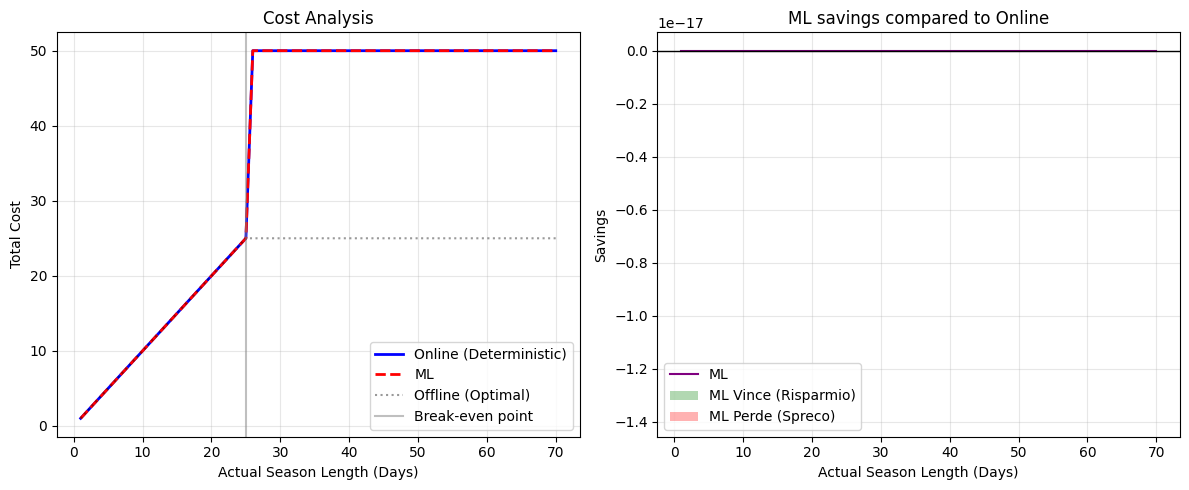

In [ ]:
max_days = 70
durations = np.arange(1, max_days + 1)

costs_opt = [min(d * rent_price, buy_price) for d in durations]
costs_det = [deterministic_rent_or_buy([1] * d, rent_price, buy_price, VERBOSE=False) for d in durations]
costs_ml = [fake_ml_rent_or_buy([0] * d, [1] * d, rent_price, buy_price, lambd=0.5, VERBOSE=False)[0] for d in durations]

if VERBOSE:
    for d in durations:
        print(f"Duration {d}: Offline={costs_opt[d-1]}, Deterministic={costs_det[d-1]}, ML={costs_ml[d-1]}")

double_figure(durations, costs_det, costs_ml, costs_opt)

As can be observed from the two graphs above, in the event that the predictor is completely incorrect, the ML-based algorithm follows the same strategy as the deterministic online algorithm. So, in the worst-case scenario, a break-even situation is observed relative to the best online algorithm.

Next, we proceed to observe the case in which the predictor is always correct.

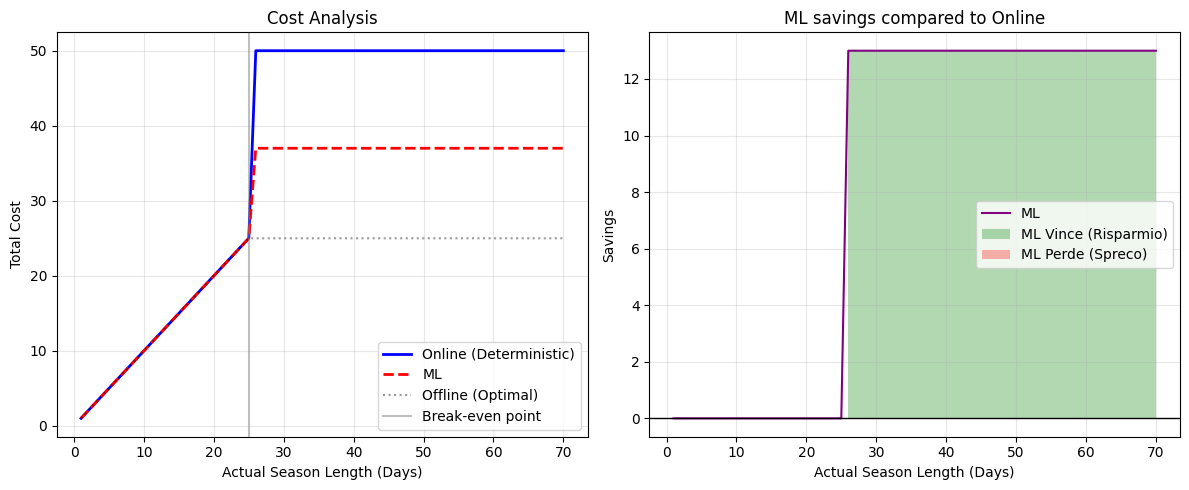

In [ ]:
costs_opt = [min(d * rent_price, buy_price) for d in durations]
costs_det = [deterministic_rent_or_buy([1] * d, rent_price, buy_price, VERBOSE=False) for d in durations]
costs_ml = [fake_ml_rent_or_buy([1] * d, [1] * d, rent_price, buy_price, lambd=0.5, VERBOSE=False)[0] for d in durations]

if VERBOSE:
    for d in durations:
        print(f"Duration {d}: Offline={costs_opt[d-1]}, Deterministic={costs_det[d-1]}, ML={costs_ml[d-1]}")

double_figure(durations, costs_det, costs_ml, costs_opt)

In this case, we observe how the framework with a predictor manages to outperform the online algorithm. In fact, as soon as the phase where it is only profitable to rent is passed, the predictive algorithm purchases the equipment earlier than the deterministic online algorithm, achieving savings for all seasons where the duration exceeds the purchase threshold.

However, the algorithm with a predictor does not reach the optimal value of the offline algorithm. This is due to the delay parameter $\lambda$, which ensures that the algorithm postpones the purchase to avoid a premature acquisition that could lead to a financial loss if the prediction were wrong (for example, predicting a long season where buying is advised, but it turns out to be a short season).

If we were to reduce $\lambda$ to a value close to 0 (implying complete trust in the predictor), and if the predictor proved to be perfectly accurate, we would notice that the predictive algorithm achieves the optimal value.

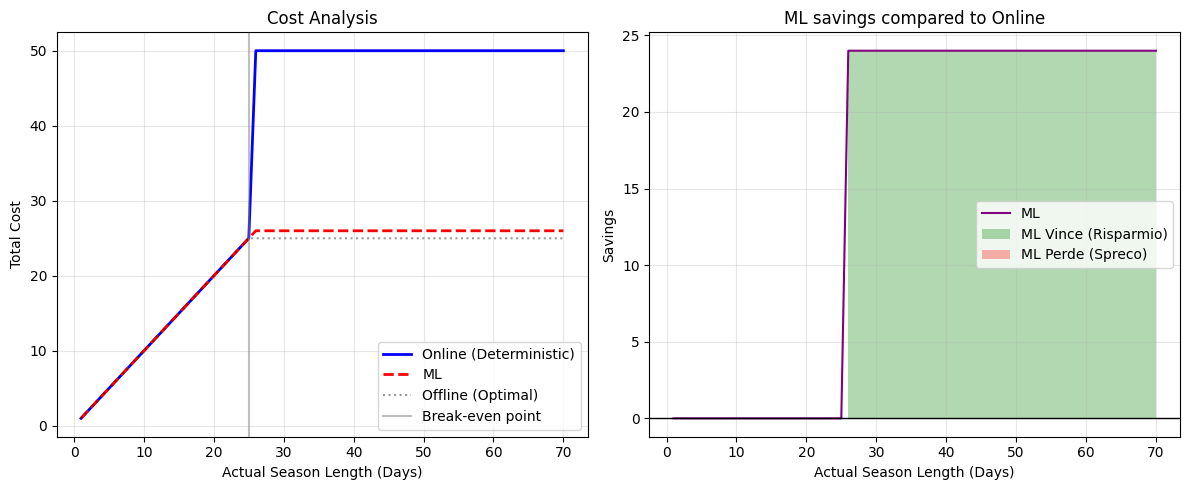

In [ ]:
costs_opt = [min(d * rent_price, buy_price) for d in durations]
costs_det = [deterministic_rent_or_buy([1] * d, rent_price, buy_price, VERBOSE=False) for d in durations]
costs_ml = [fake_ml_rent_or_buy([1] * d, [1] * d, rent_price, buy_price, lambd=0.00000001, VERBOSE=False)[0] for d in durations]

if VERBOSE:
    for d in durations:
        print(f"Duration {d}: Offline={costs_opt[d-1]}, Deterministic={costs_det[d-1]}, ML={costs_ml[d-1]}")

double_figure(durations, costs_det, costs_ml, costs_opt)


### The choice of Lambda

Therefore, when $\lambda$ is close to zero, it is as if we trust the model blindly; if $\lambda$ is equal to 1, the predictions carry no weight (and we return to the deterministic online algorithm scenario).

We must now decide on an optimal value for this parameter. A value of 0.5 might seem like a good compromise, as it would mean we trust the model as much as we distrust it. However, if we have a model with high accuracy, it would be a missed opportunity not to use that information to determine how much we can rely on it.
Thus, why not use the model's probabilities instead of a fixed $\lambda$?

The idea is to replace the arbitrarily chosen $\lambda$ parameter with a confidence measure derived directly from the model's probability outputs. This allows for improved adaptability, as a fixed $\lambda$ does not account for variations in prediction certainty across different dataset.

We adopt an entropy-based confidence scoring to quantify the model's certainty. For a binary classification with predicted probability $p$ for the positive class, the entropy is defined as:

$ Entropy(S)= -\sum^{n}_{i=1} p_i log_2 p_i$

The entropy . We convert this to a confidence score as:


Where:

- $S:$ the dataset (set of data points).
- $p_i:$ the probability of class $i$ in the dataset.
- $n:$ the number of unique classes in the dataset

The main advantage of using entropy is that it ranges from 0 to 1, the same as λ and it hasa similar behavior:

- If the model is highly certain entropy approaches 0: the algorithm can then trust the predictions more aggressively;
- If the model is uncertain entropy approaches 1: the algorithm becomes more conservative, behaving closer to the deterministic strategy.

Thus this allow the algorithm to self-calibrate it self. The confidence score automatically adapts to the model's performance on each specific dataset, eliminating the need of manual tuning of $\lambda$.

However, this approach may encounter certain issues, primarily related to the model's probability outputs. For instance, if a model overestimates or underestimates its probabilities, it could lead to an inaccurate threshold calculation, especially if these probabilities approach extreme values like 0 and 1, which can ruin the average. For this reason, the possibility of manually tuning the $\lambda$ parameter has been left.

In [ ]:
from scipy.stats import entropy

In [ ]:
def ml_rent_or_buy_enhanced(X_train, y_train, X_test, y_test, rent, buy, lambd=None, VERBOSE=False):
    cost = 0
    day_counter = 0

    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)
    daily_predictions = model.predict(X_test)

    if lambd is None:
      probabilities = model.predict_proba(X_test)[:, 1]
      entropies = []
      for prob in probabilities:
          ent = entropy([prob, 1-prob], base=2)
          entropies.append(ent)

          confidence_score = np.mean(entropies)
    else:
      confidence_score = lambd

    if daily_predictions.sum() > buy:
        purchase_day = max(1, int(buy * confidence_score))
    else:
        purchase_day = int(buy / confidence_score)
    if VERBOSE:
        print(f"lambd: {lambd}")
        print(f"DAily predictions sum: {daily_predictions.sum()}")
        print(f"buy = {buy}")
        print(f"Purchase day set to: {purchase_day}")
        print(f"Confidence Score: {confidence_score}")

    for day in y_test:
        if day == 1:
          if day_counter == purchase_day:
              cost += buy
              if VERBOSE:
                    print(f"Day {day_counter}: Buying equipment, {cost}")
              return cost, "Buying equipment", daily_predictions
          elif day_counter < buy:
              cost += rent
              if VERBOSE:
                    print(f"Day {day_counter}: Renting equipment, {cost}")
          else:
              cost += buy
              if VERBOSE:
                    print(f"Day {day_counter}: Buying equipment, {cost}")
              return cost, "Renting equipment", daily_predictions
          day_counter += 1
    return cost, "Renting equipment", daily_predictions




We will now proceed to simulate 100 mock seasons (the dataset will be the same, olnly different seed the datatset split) to evaluate whether this new method of calculating $\lambda$ performs better compared to using a fixed $\lambda$.

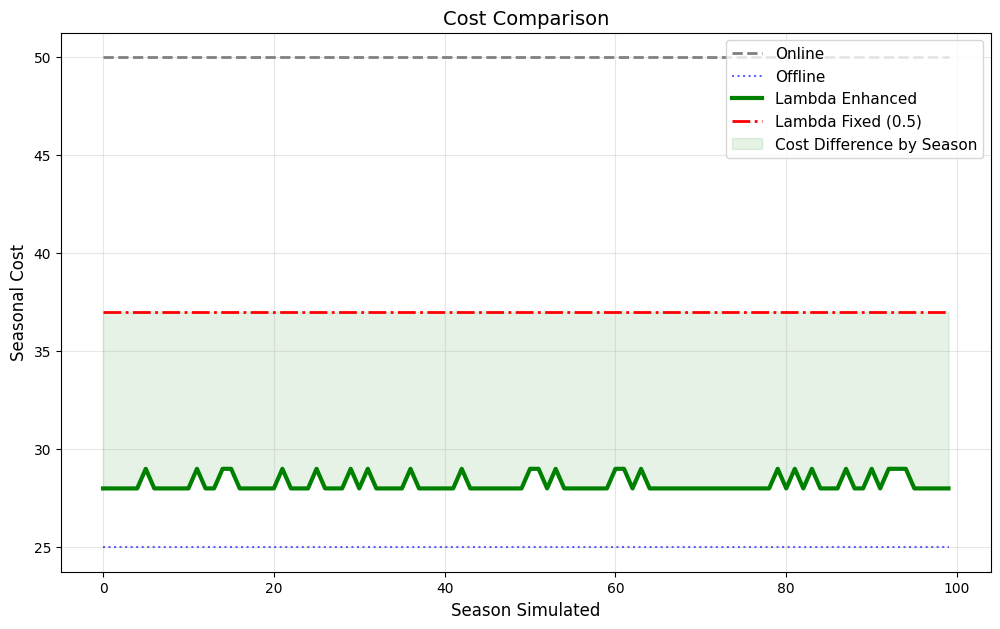

--- AVERAGE COST REPORT (over 100 seasons) ---
Average Offline Cost: 25.00
Average Deterministic Online Cost: 50.00
Average ML Lambda Fixed (0.5) Cost: 37.00
Average ML Lambda Enhanced Cost: 28.24


In [ ]:
n_seasons = 100
costs_opt = []
costs_det = []
costs_ml = []
costs_ml_naive = []

for i in range(n_seasons):
    X_train_iter, X_test_iter, y_train_iter, y_test_iter = train_test_split(X, y, test_size=0.2, random_state=i)

    c_det = deterministic_rent_or_buy(y_test_iter, rent_price, buy_price)
    costs_det.append(c_det)

    c_ml_naive, action_taken, daily_predictions = ml_rent_or_buy(X_train_iter, y_train_iter, X_test_iter, y_test_iter, rent_price, buy_price, lambd=0.5, VERBOSE=False)
    costs_ml_naive.append(c_ml_naive)

    c_opt = offline_rent_or_buy(y_test_iter, rent_price, buy_price)
    costs_opt.append(c_opt)

    c_ml, action_taken, daily_predictions = ml_rent_or_buy_enhanced(X_train_iter, y_train_iter, X_test_iter, y_test_iter, rent_price, buy_price, VERBOSE=False)
    costs_ml.append(c_ml)

plt.figure(figsize=(12, 7))
plt.plot(costs_det, label='Online', color='grey', linestyle='--', linewidth=2)
plt.plot(costs_opt, label='Offline', color='blue', linestyle=':', alpha=0.6)
plt.plot(costs_ml, label='Lambda Enhanced', color='green', linewidth=3)
plt.plot(costs_ml_naive, label='Lambda Fixed (0.5)', color='red', linestyle='-.', linewidth=2)

plt.fill_between(range(n_seasons), costs_ml, costs_ml_naive, color='green', alpha=0.1, label='Cost Difference by Season')

plt.title(f'Cost Comparison', fontsize=14)
plt.xlabel('Season Simulated', fontsize=12)
plt.ylabel('Seasonal Cost', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

plt.show()

print(f"--- AVERAGE COST REPORT (over {n_seasons} seasons) ---")
print(f"Average Offline Cost: {np.mean(costs_opt):.2f}")
print(f"Average Deterministic Online Cost: {np.mean(costs_det):.2f}")
print(f"Average ML Lambda Fixed (0.5) Cost: {np.mean(costs_ml_naive):.2f}")
print(f"Average ML Lambda Enhanced Cost: {np.mean(costs_ml):.2f}")

The Offline strategy (blue dotted line) which represents the theoretical minimum, has a cost of 25 with perfect future knowledge. The Online deterministic strategy (grey dashed line) shows the highest cost (50),  and it would be the worst-case scenario also for the models with predicitions.
The Lambda Fixed (red dash-dotted line) provides an improvement over the Online approach with a cost of 37.
And for last, the dynamic approach (solid green line) outperforms the fixed lambda, maintaining a lower cost of 28.2, rappresenting the best choice (apart for the Offline approach).

In this case, if the $\lambda$ in the fixed-lambda function had been lowered below 0.15, it would have outperformed the Enhanced $\lambda$ function. This is because the model's predictions are highly accurate; so, trusting it almost blindly will consistently return the best results.


## Conclusion

This study explored the application of algorithms with predictions to the classic Ski Rental (or Rent or Buy) decision problem. The objective was to overcome the limitations of traditional deterministic algorithms by adding machine learning-based weather predictions to optimize decision-making under uncertainty.
The proposed framework demonstrated strong results:
In the worst-case scenario (where the oracle provides completely incorrect predictions) the framework's performance match the worst-case performance of the classic deterministic online algorithm.
But the best results is obtained when the oracle provides accurate predictions, the framework's performance approaches the optimal offline counterparts.

This trust in the predictions is controlled by a $\lambda$ parameter. When $\lambda$ is low, the algorithm trust the prediction, otherwise if it is close to 1 the algorithm preform a strategy	similar to its deterministic counterpart.
This parameter can be tuned manually, but a dynamic threshold based on the entropy values provided by the model was proposed.
This threshold allows the algorithm to be self-calibrating: increasing its trust on the prediction when confidence is high and reverting to a more conservative strategy when uncertainty rises.

## Bibliography

* Mitzenmacher, M., & Vassilvitskii, S. (2020). "Algorithms with Predictions". *Communications of the ACM*.

* https://www.geeksforgeeks.org/data-science/how-to-calculate-entropy-in-decision-tree/